In [1]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import nibabel as nib

def read_nifti(path):
    img = nib.load(path)

    return img.get_fdata(),img.shape
path = "/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTs/NG4118_Segments_0000.nii.gz"
data, _  = read_nifti(path)
main_title = f"NG4118, {_}"
def _slice_visualize_regions(slice_no):

    
    # Calculate the number of rows and columns needed to display 24 regions
    num_rows = 4
    num_cols = 6
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 6))

    for i in range(num_rows):
        for j in range(num_cols):
            index = i * num_cols + j
            if index < len(data):
                # Extract the middle slice of the 3D volume
                roi = data == index
                middle_slice = roi.shape[2] // 2
                axes[i, j].imshow(roi[:, :, slice_no], cmap='gray')

                axes[i, j].set_title(f"Region {index}, Slice {slice_no}")
                axes[i, j].axis('off')
            else:
                # Hide empty subplots
                axes[i, j].axis('off')
        # Add main title
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()

slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(_slice_visualize_regions, slice_no=slice_slider)

interactive(children=(IntSlider(value=206, description='Slice', max=412), Output()), _dom_classes=('widget-int…

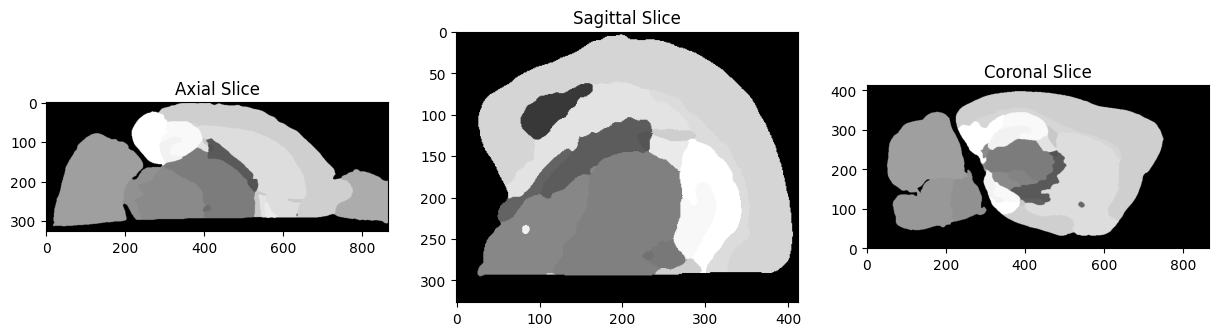

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt



# Plot slices of the image along different axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot axial slice
axes[0].imshow(data[:, :, data.shape[2] // 2], cmap='gray')
axes[0].set_title('Axial Slice')

# Plot sagittal slice
axes[1].imshow(data[:, data.shape[1] // 2, :], cmap='gray')
axes[1].set_title('Sagittal Slice')

# Plot coronal slice
axes[2].imshow(data[data.shape[0] // 2, :, :].T, cmap='gray', origin='lower')
axes[2].set_title('Coronal Slice')

plt.show()


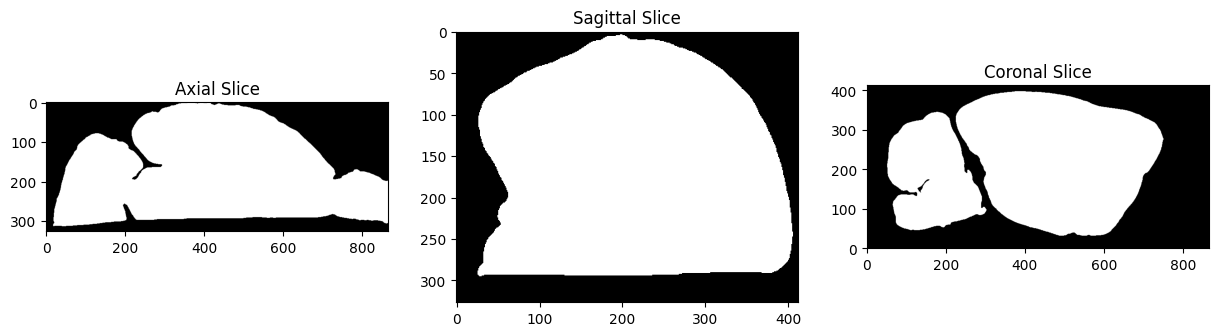

In [3]:
import numpy as np

# Threshold the image data to create a binary mask
binary_mask = np.where(data != 0, 1, 0)


# Plot slices of the image along different axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot axial slice
axes[0].imshow(binary_mask[:, :, binary_mask.shape[2] // 2], cmap='gray')
axes[0].set_title('Axial Slice')

# Plot sagittal slice
axes[1].imshow(binary_mask[:, binary_mask.shape[1] // 2, :], cmap='gray')
axes[1].set_title('Sagittal Slice')

# Plot coronal slice
axes[2].imshow(binary_mask[binary_mask.shape[0] // 2, :, :].T, cmap='gray', origin='lower')
axes[2].set_title('Coronal Slice')

plt.show()


In [5]:
import nibabel as nib
import numpy as np

# Load the NIfTI image
img = nib.load(path)  # Replace 'your_image.nii.gz' with the path to your NIfTI file

# Get the image data
data = img.get_fdata()

# Threshold the image data to create a binary mask
binary_mask = np.where(data != 0, 1, 0).astype(np.uint8)  # Convert to uint8 data type

# Create a new NIfTI image using the binary mask
binary_img = nib.Nifti1Image(binary_mask, img.affine)

# Save the binary NIfTI image
nib.save(binary_img, '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/data/report/binary_mask.nii.gz')
